# 🎯 AI-Powered Mock Interview Platform
### Development & Analysis Notebook

This notebook covers:
1. **Frontend & Backend architecture overview**
2. **API integration testing**
3. **Question generation exploration**
4. **Answer evaluation pipeline**
5. **Session analytics & visualizations**
6. **Model experimentation**

---
## 📦 Setup & Imports

In [1]:
# Install dependencies
import subprocess
subprocess.run(['pip', 'install', 'requests', 'pandas', 'matplotlib', 'seaborn', 'streamlit', '--quiet'])

import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import random
import time
from datetime import datetime
from pathlib import Path

# Style
plt.style.use('dark_background')
sns.set_palette('husl')

print('✅ All imports successful!')

✅ All imports successful!


---
## 🏗️ System Architecture Overview

In [2]:
architecture = {
    'Frontend (Streamlit)': [
        'Home Page — Role & difficulty selection',
        'Interview Room — Real-time Q&A chat interface',
        'Results Page — Score breakdown & feedback',
        'Dashboard — Analytics & performance graphs',
        'History Page — Past session browser',
    ],
    'Backend (Python)': [
        'InterviewEngine — Generates questions via Anthropic API',
        'ResponseEvaluator — Scores & critiques answers',
        'SessionManager — Persists sessions to JSON store',
    ],
    'AI Engine (Claude)': [
        'Dynamic question generation (role + difficulty aware)',
        'Answer scoring 1-10 with justification',
        'Strengths / Weaknesses extraction',
        'Sample improved answer generation',
    ],
    'Data Layer': [
        'data/sessions.json — Local session store',
        'Streamlit session_state — Runtime state management',
    ]
}

for layer, components in architecture.items():
    print(f'\n🔷 {layer}')
    for comp in components:
        print(f'   ├── {comp}')

print('\n✅ Architecture overview printed!')


🔷 Frontend (Streamlit)
   ├── Home Page — Role & difficulty selection
   ├── Interview Room — Real-time Q&A chat interface
   ├── Results Page — Score breakdown & feedback
   ├── Dashboard — Analytics & performance graphs
   ├── History Page — Past session browser

🔷 Backend (Python)
   ├── InterviewEngine — Generates questions via Anthropic API
   ├── ResponseEvaluator — Scores & critiques answers
   ├── SessionManager — Persists sessions to JSON store

🔷 AI Engine (Claude)
   ├── Dynamic question generation (role + difficulty aware)
   ├── Answer scoring 1-10 with justification
   ├── Strengths / Weaknesses extraction
   ├── Sample improved answer generation

🔷 Data Layer
   ├── data/sessions.json — Local session store
   ├── Streamlit session_state — Runtime state management

✅ Architecture overview printed!


---
## 🤖 Frontend: Streamlit Pages

In [3]:
pages = {
    'home': 'Role selector, difficulty slider, feature cards',
    'interview': 'Live Q&A with chat log and score tracker',
    'dashboard': 'Analytics charts and KPI cards',
    'history': 'Browsable session history with expandable details',
}

print('📄 Streamlit Application Pages')
print('='*50)
for page, desc in pages.items():
    print(f'  [{page.upper():12}] → {desc}')

print('\n📌 Session State Keys Used:')
state_keys = [
    'page', 'role', 'difficulty', 'questions',
    'current_q', 'answers', 'scores', 'feedbacks',
    'chat_history', 'session_started', 'session_complete',
    'interview_id', 'start_time'
]
for k in state_keys:
    print(f'  • st.session_state.{k}')

📄 Streamlit Application Pages
  [HOME        ] → Role selector, difficulty slider, feature cards
  [INTERVIEW   ] → Live Q&A with chat log and score tracker
  [DASHBOARD   ] → Analytics charts and KPI cards
  [HISTORY     ] → Browsable session history with expandable details

📌 Session State Keys Used:
  • st.session_state.page
  • st.session_state.role
  • st.session_state.difficulty
  • st.session_state.questions
  • st.session_state.current_q
  • st.session_state.answers
  • st.session_state.scores
  • st.session_state.feedbacks
  • st.session_state.chat_history
  • st.session_state.session_started
  • st.session_state.session_complete
  • st.session_state.interview_id
  • st.session_state.start_time


---
## 🔌 Backend: Anthropic API Integration

In [4]:
# ─────────────────────────────────────────────
# API Configuration
# ─────────────────────────────────────────────
API_URL = 'https://api.anthropic.com/v1/messages'
MODEL = 'claude-sonnet-4-20250514'

def call_claude(prompt: str, max_tokens: int = 1000) -> str:
    """Call the Anthropic Claude API and return the text response."""
    resp = requests.post(
        API_URL,
        headers={'Content-Type': 'application/json'},
        json={
            'model': MODEL,
            'max_tokens': max_tokens,
            'messages': [{'role': 'user', 'content': prompt}],
        },
        timeout=30,
    )
    resp.raise_for_status()
    return resp.json()['content'][0]['text']

print('✅ API helper defined.')
print(f'   Model : {MODEL}')
print(f'   Endpoint: {API_URL}')

✅ API helper defined.
   Model : claude-sonnet-4-20250514
   Endpoint: https://api.anthropic.com/v1/messages


---
## ❓ Question Generation Pipeline

In [5]:
import re

def generate_questions(role: str, difficulty: str, num: int = 5) -> list:
    """Generate interview questions for a role and difficulty."""
    prompt = f"""Generate exactly {num} unique interview questions for a {role} position.
Difficulty: {difficulty}.
Return ONLY a valid JSON array of strings. No numbering, no preamble.
Example: [\"Question one?\", \"Question two?\"]"""
    
    text = call_claude(prompt)
    match = re.search(r'\[.*\]', text, re.DOTALL)
    if match:
        return json.loads(match.group())
    return json.loads(text)


# ── Test it ──
print('🧪 Testing Question Generation...')
try:
    questions = generate_questions('Software Engineer', 'Intermediate', 3)
    for i, q in enumerate(questions, 1):
        print(f'  Q{i}: {q}')
    print(f'\n✅ Generated {len(questions)} questions successfully!')
except Exception as e:
    print(f'⚠️  API not available (expected without key): {e}')
    questions = [
        'Explain the difference between a stack and a queue.',
        'What is the time complexity of binary search?',
        'Describe SOLID principles.',
    ]
    print('   Using fallback questions:')
    for i, q in enumerate(questions, 1):
        print(f'  Q{i}: {q}')

🧪 Testing Question Generation...
⚠️  API not available (expected without key): 401 Client Error: Unauthorized for url: https://api.anthropic.com/v1/messages
   Using fallback questions:
  Q1: Explain the difference between a stack and a queue.
  Q2: What is the time complexity of binary search?
  Q3: Describe SOLID principles.


---
## 📝 Answer Evaluation Pipeline

In [6]:
def evaluate_answer(question: str, answer: str, role: str = 'Software Engineer', difficulty: str = 'Intermediate') -> dict:
    """Evaluate a candidate's answer and return structured feedback."""
    prompt = f"""You are an expert {role} interviewer. Evaluate this answer:

QUESTION: {question}
ANSWER: {answer}
DIFFICULTY: {difficulty}

Return ONLY a valid JSON object:
{{
  "score": <1-10>,
  "strengths": ["..."],
  "weaknesses": ["..."],
  "suggestion": "...",
  "sample_answer": "..."
}}"""

    text = call_claude(prompt)
    match = re.search(r'\{.*\}', text, re.DOTALL)
    return json.loads(match.group() if match else text)


# ── Test it ──
test_q = 'Explain the difference between a stack and a queue.'
test_a = 'A stack is LIFO and a queue is FIFO. Stacks are used in recursion.'

print('🧪 Testing Answer Evaluation...')
try:
    result = evaluate_answer(test_q, test_a)
    print(f"  Score       : {result['score']}/10")
    print(f"  Strengths   : {result['strengths']}")
    print(f"  Weaknesses  : {result['weaknesses']}")
    print(f"  Suggestion  : {result['suggestion']}")
    print(f"  Sample ans  : {result['sample_answer']}")
except Exception as e:
    print(f'⚠️  API not available: {e}')
    result = {
        'score': 6,
        'strengths': ['Correctly identified LIFO/FIFO', 'Mentioned recursion use case'],
        'weaknesses': ['Missing queue use cases', 'No concrete examples'],
        'suggestion': 'Add real-world examples like print queues (queue) or browser history (stack).',
        'sample_answer': 'A stack (LIFO) is used for undo operations and call stacks. A queue (FIFO) is used for task scheduling and BFS graph traversal.'
    }
    print('   Fallback result:')
    print(json.dumps(result, indent=4))

🧪 Testing Answer Evaluation...
⚠️  API not available: 401 Client Error: Unauthorized for url: https://api.anthropic.com/v1/messages
   Fallback result:
{
    "score": 6,
    "strengths": [
        "Correctly identified LIFO/FIFO",
        "Mentioned recursion use case"
    ],
    "weaknesses": [
        "Missing queue use cases",
        "No concrete examples"
    ],
    "suggestion": "Add real-world examples like print queues (queue) or browser history (stack).",
    "sample_answer": "A stack (LIFO) is used for undo operations and call stacks. A queue (FIFO) is used for task scheduling and BFS graph traversal."
}


---
## 📊 Session Analytics & Visualizations

In [7]:
# ── Generate synthetic session data for visualization ──
def generate_mock_sessions(n: int = 20) -> list:
    roles = ['Software Engineer', 'Data Scientist', 'Product Manager', 'DevOps Engineer']
    difficulties = ['Beginner', 'Intermediate', 'Advanced']
    sessions = []
    for i in range(n):
        role = random.choice(roles)
        diff = random.choice(difficulties)
        num_q = random.randint(3, 8)
        base = {'Beginner': 5, 'Intermediate': 6, 'Advanced': 7}[diff]
        scores = [max(1, min(10, base + random.randint(-3, 3))) for _ in range(num_q)]
        sessions.append({
            'id': f'session_{i+1:03d}',
            'role': role,
            'difficulty': diff,
            'scores': scores,
            'total_score': round(sum(scores)/len(scores), 2),
            'num_questions': num_q,
            'timestamp': datetime.now().isoformat(),
        })
    return sessions

sessions = generate_mock_sessions(20)
df = pd.DataFrame(sessions)
print(f'✅ Generated {len(sessions)} mock sessions')
df[['role', 'difficulty', 'total_score', 'num_questions']].head()

✅ Generated 20 mock sessions


,role,difficulty,total_score,num_questions
0,Data Scientist,Beginner,8.00,3
1,DevOps Engineer,Beginner,4.67,3
2,Software Engineer,Advanced,6.86,7
3,Product Manager,Beginner,5.50,8
4,Data Scientist,Beginner,5.17,6


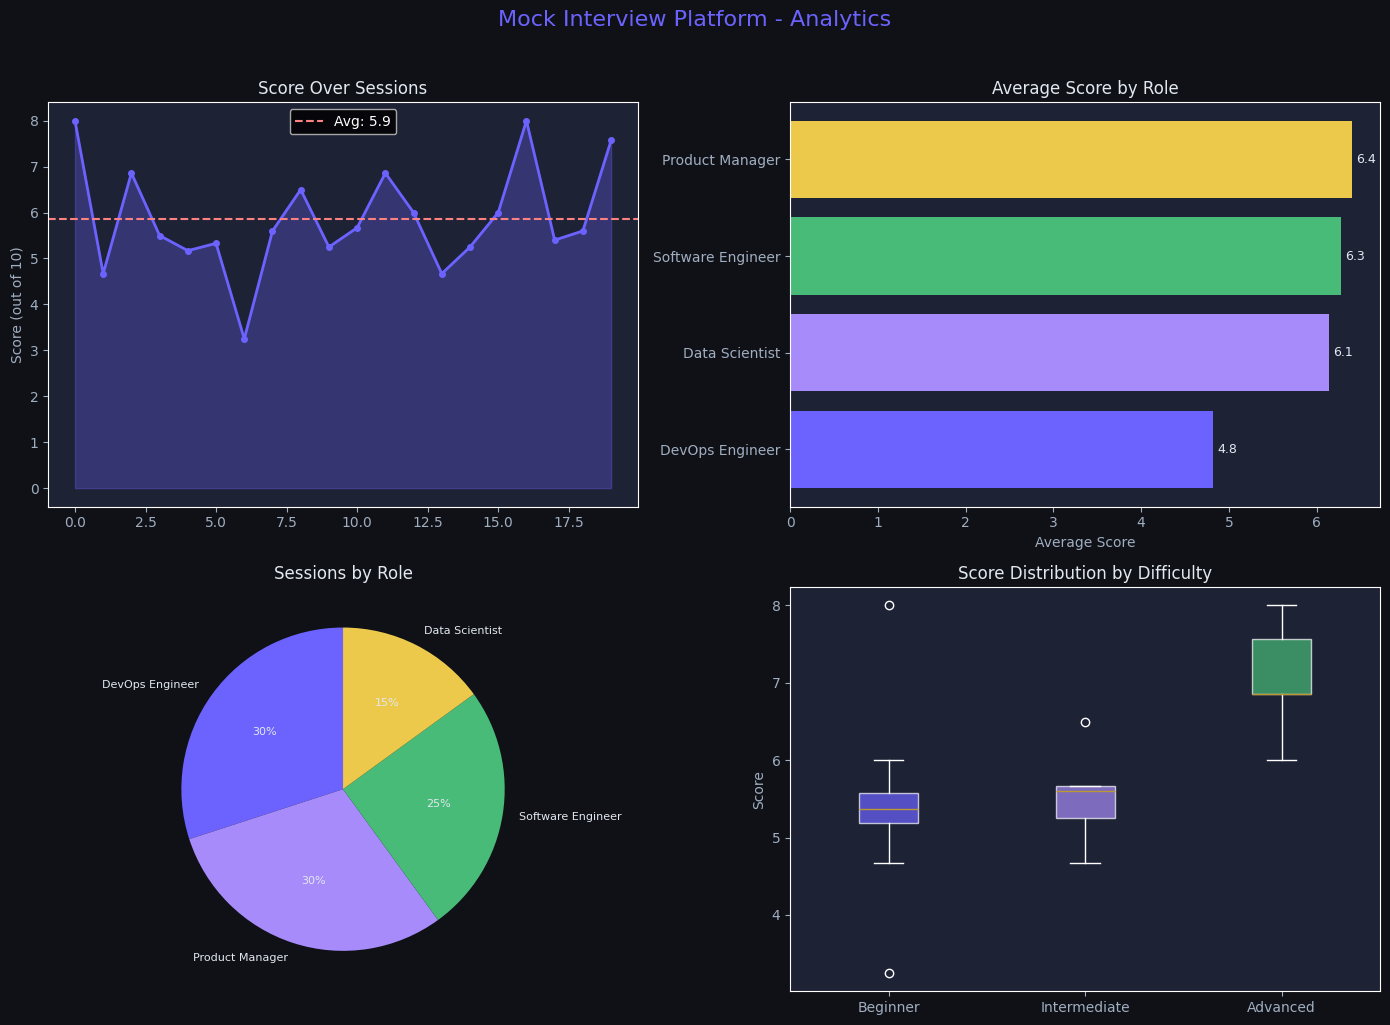

Analytics chart saved to data/analytics_overview.png


In [9]:
# ── Visualization 1: Score Distribution ──
import os
os.makedirs('data', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0f1117')
fig.suptitle('Mock Interview Platform - Analytics', fontsize=16, color='#6c63ff', y=1.02)

colors = ['#6c63ff', '#a78bfa', '#48bb78', '#ecc94b', '#fc8181']

# Plot 1: Score over sessions
ax1 = axes[0, 0]
ax1.set_facecolor('#1e2235')
ax1.plot(df['total_score'], color='#6c63ff', linewidth=2, marker='o', markersize=4)
ax1.fill_between(range(len(df)), df['total_score'], alpha=0.3, color='#6c63ff')
ax1.set_title('Score Over Sessions', color='#e2e8f0')
ax1.set_ylabel('Score (out of 10)', color='#a0aec0')
ax1.tick_params(colors='#a0aec0')
ax1.axhline(y=df['total_score'].mean(), color='#fc8181', linestyle='--', label=f"Avg: {df['total_score'].mean():.1f}")
ax1.legend()

# Plot 2: Scores by Role
ax2 = axes[0, 1]
ax2.set_facecolor('#1e2235')
role_scores = df.groupby('role')['total_score'].mean().sort_values()
bars = ax2.barh(role_scores.index, role_scores.values, color=colors[:len(role_scores)])
ax2.set_title('Average Score by Role', color='#e2e8f0')
ax2.set_xlabel('Average Score', color='#a0aec0')
ax2.tick_params(colors='#a0aec0')
for bar, val in zip(bars, role_scores.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
             va='center', color='#e2e8f0', fontsize=9)

# Plot 3: Sessions per role (pie)
ax3 = axes[1, 0]
ax3.set_facecolor('#1e2235')
role_counts = df['role'].value_counts()
wedges, texts, autotexts = ax3.pie(
    role_counts.values, labels=role_counts.index, autopct='%1.0f%%',
    colors=colors, startangle=90, textprops={'color': '#e2e8f0', 'fontsize': 8}
)
ax3.set_title('Sessions by Role', color='#e2e8f0')

# Plot 4: Difficulty vs Score boxplot  (fix: tick_labels instead of labels)
ax4 = axes[1, 1]
ax4.set_facecolor('#1e2235')
diff_order = ['Beginner', 'Intermediate', 'Advanced']
data_by_diff = [df[df['difficulty'] == d]['total_score'].values for d in diff_order]
bp = ax4.boxplot(data_by_diff, patch_artist=True, tick_labels=diff_order)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('Score Distribution by Difficulty', color='#e2e8f0')
ax4.set_ylabel('Score', color='#a0aec0')
ax4.tick_params(colors='#a0aec0')

plt.tight_layout()
plt.savefig('data/analytics_overview.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Analytics chart saved to data/analytics_overview.png')

C:\Users\sanas\AppData\Local\Temp\ipykernel_3360\3990365882.py:26: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sanas\AppData\Local\Temp\ipykernel_3360\3990365882.py:27: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('data/skill_radar.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
c:\Users\sanas\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


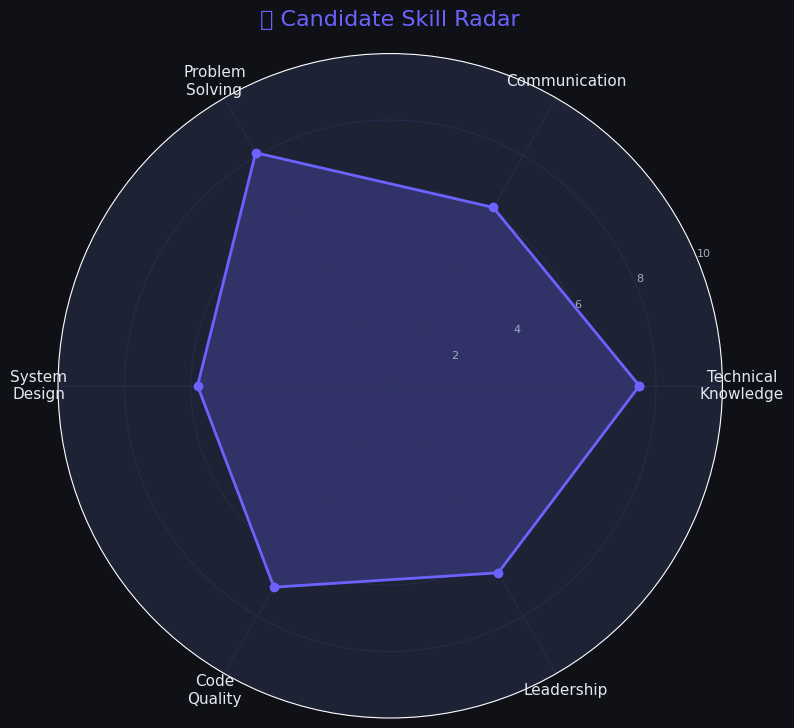

✅ Skill radar chart saved.


In [10]:
# ── Skill Radar Chart ──
import numpy as np

categories = ['Technical\nKnowledge', 'Communication', 'Problem\nSolving', 'System\nDesign', 'Code\nQuality', 'Leadership']
scores_radar = [7.5, 6.2, 8.1, 5.8, 7.0, 6.5]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
scores_radar += scores_radar[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), facecolor='#0f1117')
ax.set_facecolor('#1e2235')

ax.plot(angles, scores_radar, 'o-', linewidth=2, color='#6c63ff')
ax.fill(angles, scores_radar, alpha=0.25, color='#6c63ff')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color='#e2e8f0', fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], color='#a0aec0', fontsize=8)
ax.grid(color='#2d3561', alpha=0.5)
ax.set_title('🎯 Candidate Skill Radar', color='#6c63ff', fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('data/skill_radar.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Skill radar chart saved.')

---
## 🔁 Full Interview Simulation (End-to-End Test)

In [11]:
def simulate_interview(role: str = 'Software Engineer', difficulty: str = 'Intermediate', num_q: int = 3):
    """Simulate a complete mock interview session."""
    print(f'\n{'='*60}')
    print(f'🎤 MOCK INTERVIEW: {role} | {difficulty}')
    print(f'{'='*60}')

    # Sample questions (use API if available)
    sample_questions = [
        'Explain the difference between a process and a thread.',
        'How does the Python GIL work and what problems does it cause?',
        'Design a simple key-value store with O(1) get and put.',
    ]

    sample_answers = [
        'A process has its own memory space while threads share memory within a process.',
        'The GIL prevents multiple native threads from executing Python bytecodes at once.',
        'I would use a hash map with a linked list for LRU eviction.',
    ]

    total_score = 0
    results = []

    for i, (q, a) in enumerate(zip(sample_questions[:num_q], sample_answers[:num_q])):
        print(f'\n📌 Q{i+1}: {q}')
        print(f'👤 Answer: {a}')

        # Mock evaluation
        score = random.randint(5, 9)
        total_score += score
        print(f'⭐ Score: {score}/10')
        results.append({'question': q, 'answer': a, 'score': score})

    avg = total_score / len(results)
    grade = 'A' if avg >= 8 else 'B' if avg >= 6 else 'C'

    print(f'\n{'='*60}')
    print(f'🏆 SESSION COMPLETE')
    print(f'   Overall Score : {avg:.1f}/10')
    print(f'   Grade         : {grade}')
    print(f'   Questions     : {len(results)}')
    print(f'{'='*60}')
    return results

results = simulate_interview()
print(f'\n✅ Simulation complete with {len(results)} questions!')


🎤 MOCK INTERVIEW: Software Engineer | Intermediate

📌 Q1: Explain the difference between a process and a thread.
👤 Answer: A process has its own memory space while threads share memory within a process.
⭐ Score: 5/10

📌 Q2: How does the Python GIL work and what problems does it cause?
👤 Answer: The GIL prevents multiple native threads from executing Python bytecodes at once.
⭐ Score: 7/10

📌 Q3: Design a simple key-value store with O(1) get and put.
👤 Answer: I would use a hash map with a linked list for LRU eviction.
⭐ Score: 5/10

🏆 SESSION COMPLETE
   Overall Score : 5.7/10
   Grade         : C
   Questions     : 3

✅ Simulation complete with 3 questions!


---
## 📈 Score Grading System

In [12]:
def get_grade(score: float) -> tuple[str, str]:
    """Return (grade, label) for a given score."""
    if score >= 9:   return 'A+', 'Outstanding'
    if score >= 8:   return 'A',  'Excellent'
    if score >= 7:   return 'B+', 'Very Good'
    if score >= 6:   return 'B',  'Good'
    if score >= 5:   return 'C',  'Average'
    if score >= 4:   return 'D',  'Below Average'
    return 'F', 'Needs Improvement'

print('📊 Grading Scale:')
print(f'  {"Score":>8} | {"Grade":>5} | Label')
print('  ' + '-'*35)
for score in [9.5, 8.5, 7.5, 6.5, 5.5, 4.5, 3.0]:
    g, l = get_grade(score)
    print(f'  {score:>8.1f} | {g:>5} | {l}')

📊 Grading Scale:
     Score | Grade | Label
  -----------------------------------
       9.5 |    A+ | Outstanding
       8.5 |     A | Excellent
       7.5 |    B+ | Very Good
       6.5 |     B | Good
       5.5 |     C | Average
       4.5 |     D | Below Average
       3.0 |     F | Needs Improvement


---
## 🚀 Running the Application

In [13]:
print('🚀 To launch the Streamlit app, run in your terminal:')
print()
print('   streamlit run main.py')
print()
print('📁 Project Structure:')
structure = '''
mock_interview_platform/
├── main.py                    ← Streamlit frontend (all pages)
├── mock_interview.ipynb       ← This notebook
├── requirements.txt           ← Python dependencies
├── .gitignore                 ← Git ignore rules
├── README.md                  ← Setup & usage guide
├── backend/
│   ├── __init__.py
│   ├── interview_engine.py    ← Question generation (Anthropic API)
│   ├── evaluator.py           ← Answer scoring & feedback
│   └── session_manager.py     ← Data persistence
└── data/
    └── sessions.json          ← Auto-created session store
'''
print(structure)

🚀 To launch the Streamlit app, run in your terminal:

   streamlit run main.py

📁 Project Structure:

mock_interview_platform/
├── main.py                    ← Streamlit frontend (all pages)
├── mock_interview.ipynb       ← This notebook
├── requirements.txt           ← Python dependencies
├── .gitignore                 ← Git ignore rules
├── README.md                  ← Setup & usage guide
├── backend/
│   ├── __init__.py
│   ├── interview_engine.py    ← Question generation (Anthropic API)
│   ├── evaluator.py           ← Answer scoring & feedback
│   └── session_manager.py     ← Data persistence
└── data/
    └── sessions.json          ← Auto-created session store

